### Contexto del Problema
En el ámbito médico predecir cómo avanzará una enfermedad crónica es fundamental para el tratamiento preventivo. El método tradicional para evaluar el avance de la diabetes implica medir variables clínicas iniciales y luego esperar un año entero para evaluar la progresión real del paciente.

El Problema: Esperar un año para saber si la enfermedad avanza agresivamente significa perder una ventana crítica de tiempo donde se podrían aplicar intervenciones preventivas (dieta, ejercicio, medicación).
El Objetivo: Crear un modelo de Machine Learning capaz de predecir la "progresión cuantitativa" de la diabetes un año después, basándose únicamente en mediciones basales (tomadas en el día 0), permitiendo a los médicos anticiparse a la enfermedad.

### Dataset
Utilizaremos el dataset clínico de Diabetes (load_diabetes de scikit-learn), que contiene datos de 442 pacientes.

Nota importante sobre los datos: Para este conjunto, scikit-learn entrega las variables predictoras estandarizadas (escaladas para tener media 0 y suma de cuadrados igual a 1). Esto es normal en Machine Learning médico para comparar variables de distintas escalas.

### Reto Matemático
El cuerpo humano es un sistema complejo. La relación entre ciertos niveles en sangre y la progresión de la enfermedad tiene interacciones no lineales. Contrastaremos modelos lineales con algoritmos de ensamble (basados en árboles) para ver cuál captura mejor esta biología compleja.

### Variables Predictoras
- Edad (Age): Edad del paciente.
- Sexo (Sex): Sexo del paciente.
- IMC (BMI): Índice de Masa Corporal.
- PAM (BP): Presión Arterial Media.
- Colesterol_Total (S1/tc): Células T / Colesterol Total en suero.
- LDL (S2/ldl): Lipoproteínas de Baja Densidad
- HDL (S3/hdl): Lipoproteínas de Alta Densidad.
- Ratio_Colesterol (S4/tch): Colesterol total / HDL.
- Trigliceridos (S5/ltg): Logaritmo del nivel de triglicéridos en suero.
- Glucosa (S6/glu): Nivel de azúcar en sangre.

### Variable Objetivo
- Progresion (Target): Medida cuantitativa de la progresión de la enfermedad un año después de las pruebas iniciales (valores enteros entre 25 y 346)

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

### CARGA DEL DATASET

In [2]:
# Carga del dataset original
diabetes = load_diabetes()
df = pd.DataFrame(data=np.c_[diabetes['data'], diabetes['target']], 
                  columns=diabetes['feature_names'] + ['target'])
print("Columnas originales:", df.columns.tolist())

Columnas originales: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


In [3]:
# 2. Renombrar columnas a español
df.columns = ['Edad', 'Sexo', 'IMC', 'PAM', 'Colesterol_Total', 'LDL', 
              'HDL', 'Ratio_Colesterol', 'Trigliceridos', 'Glucosa', 'Progresion']

In [4]:
df.head()

,Edad,Sexo,IMC,PAM,Colesterol_Total,LDL,HDL,Ratio_Colesterol,Trigliceridos,Glucosa,Progresion
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.describe()

,Edad,Sexo,IMC,PAM,Colesterol_Total,LDL,HDL,Ratio_Colesterol,Trigliceridos,Glucosa,Progresion
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
print("Forma del dataset:", df.shape)

Forma del dataset: (442, 11)


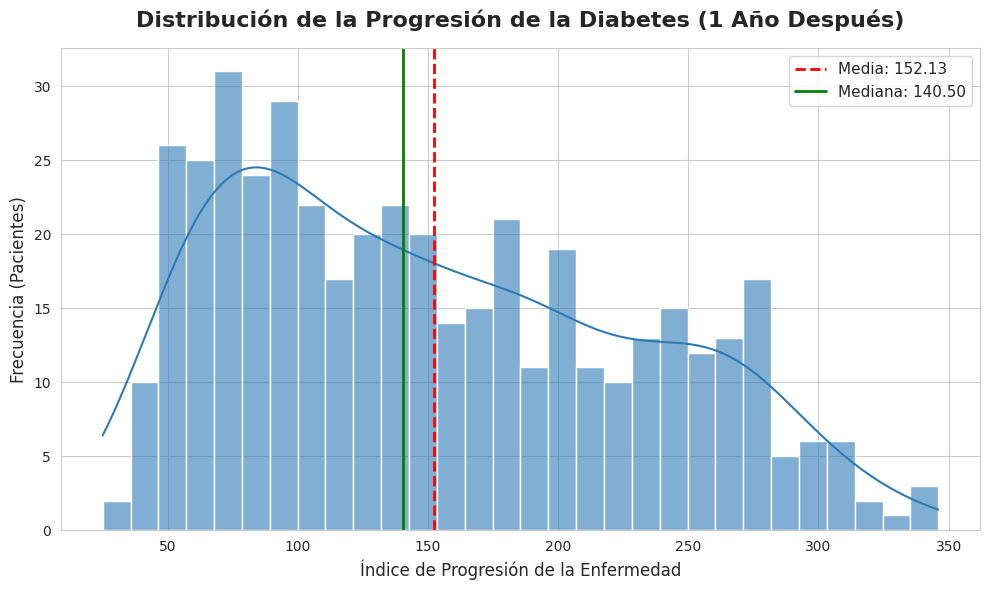

Asimetría (Skewness): 0.44
-> La distribución es bastante SIMÉTRICA (Cercana a Normal).


In [7]:
# Configuración de estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 1. Crear el Histograma con la curva de densidad (KDE)
sns.histplot(data=df, x='Progresion', kde=True, color='#2c7bb6', bins=30, alpha=0.6)

# 2. Calcular Media y Mediana
media = df['Progresion'].mean()
mediana = df['Progresion'].median()

# 3. Dibujar líneas verticales
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

# 4. Títulos y Etiquetas Profesionales
plt.title('Distribución de la Progresión de la Diabetes (1 Año Después)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Índice de Progresión de la Enfermedad', fontsize=12)
plt.ylabel('Frecuencia (Pacientes)', fontsize=12)

# 5. Añadir leyenda
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Asimetría (Skewness): {df['Progresion'].skew():.2f}")
if -0.5 < df['Progresion'].skew() < 0.5:
    print("-> La distribución es bastante SIMÉTRICA (Cercana a Normal).")
else:
    print("-> La distribución está SESGADA (No es perfectamente Normal).")

La asimetría (Skewness = 0.44) cae dentro de la "zona segura". Tenemos una base de pacientes representativa, no solo casos leves ni solo casos terminales. La media (152.1) es muy cercana a la mediana (140.5). Al estar balanceada, los modelos de predicción no tendrán problemas graves de sesgo hacia un solo extremo clínico.

In [9]:
# Verificar nulos
print("Recuento de Valores Nulos")
print(df.isnull().sum())

Recuento de Valores Nulos
Edad                0
Sexo                0
IMC                 0
PAM                 0
Colesterol_Total    0
LDL                 0
HDL                 0
Ratio_Colesterol    0
Trigliceridos       0
Glucosa             0
Progresion          0
dtype: int64


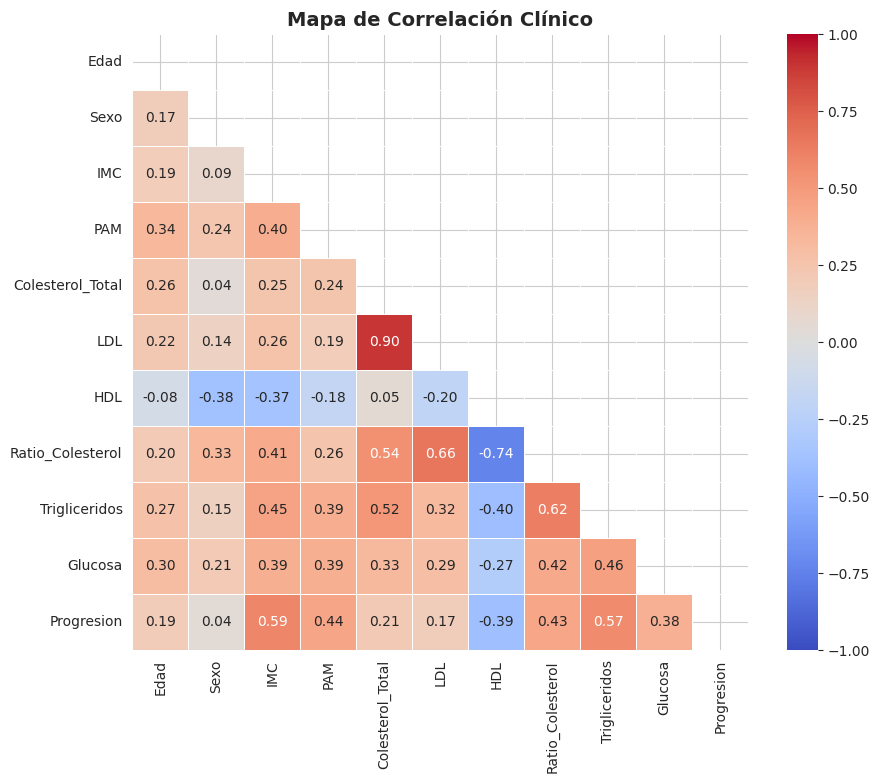

In [10]:
# Calcular la correlación
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, linewidths=0.5, square=True)

plt.title('Mapa de Correlación Clínico', fontsize=14, fontweight='bold')
plt.show()

**Análisis de Correlaciones:**

- Los "Agravantes" (Correlación Positiva Alta):

IMC (0.59): Física/Medicina: El peso relativo a la altura es el predictor lineal más fuerte. Mayor grasa corporal genera resistencia a la insulina crónicamente.

Triglicéridos (0.57): Niveles altos de grasa en sangre influyen fuertemente en el daño metabólico a largo plazo.

- El "Protector" (Correlación Negativa):

HDL (-0.39): Conocido como el colesterol "bueno". Actúa como recolector de grasa. Cuanto más alto es este valor, menor es el índice de progresión del paciente.

- Las variables "Contextuales" (Correlaciones Débiles):

Edad (0.19) y Sexo (0.04): Curiosamente, la edad no determina fuertemente el avance rápido por sí sola en un año, comparado con factores directamente metabólicos como el IMC o los triglicéridos.

### PREPARACIÓN DE LOS DATOS PARA EL ENTRENAMIENTO DEL MODELO

In [11]:
# Definir X e y
X = df.drop('Progresion', axis=1)
feature_names = X.columns
y = df['Progresion']

In [12]:
# Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# KFold
cv_regresion = KFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
historial_modelos = []

In [15]:
def calcular_metricas(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {'Modelo': nombre_modelo, 'MAE': mae, 'RMSE': rmse, 'R2 (Calidad)': r2}

In [16]:
def plot_real_vs_pred(model, X_test, y_test, model_name, color='blue'):
    y_pred = model.predict(X_test)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color=color, s=60)
    m = max(y_test.max(), y_pred.max())
    plt.plot([0, m], [0, m], 'r--', lw=2, label='Predicción Perfecta')
    plt.title(f'Validación: {model_name} (Real vs Estimado)', fontsize=14, fontweight='bold')
    plt.xlabel('Progresión Real', fontsize=12)
    plt.ylabel(f'Predicción {model_name}', fontsize=12)
    plt.legend()
    plt.axis('square')
    plt.show()

In [17]:
def get_top_features(model, feature_names, top_n=10):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        total_importance = importances.sum()
        importances_normalized = importances / total_importance if total_importance > 0 else importances
        feat_imp = pd.Series(importances_normalized, index=feature_names).sort_values(ascending=False)
        return feat_imp.head(top_n)
    return pd.Series()

In [18]:
def plot_feature_importance(model, feature_names, model_name, palette='viridis'):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)
        plt.title(f'Ranking de Variables Clínicas: {model_name}', fontsize=14, fontweight='bold')
        plt.xlabel('Importancia Relativa', fontsize=12)
        plt.ylabel('Marcadores Clínicos', fontsize=12)
        plt.show()

In [19]:
def plot_residuals(model, X_test, y_test, model_name, color='purple'):
    y_pred = model.predict(X_test)
    residuos = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=residuos, color=color, alpha=0.6, s=60)
    plt.axhline(0, color='black', linestyle='--', lw=2, label='Error Cero')
    plt.axhline(30, color='gray', linestyle=':', alpha=0.5)
    plt.axhline(-30, color='gray', linestyle=':', alpha=0.5)
    plt.title(f'Diagnóstico de Residuos: {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Progresión REAL', fontsize=12)
    plt.ylabel('Error (Real - Predicho)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### RANDOM FOREST

In [20]:
dict_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", 1.0],
    "criterion": ["squared_error"]
}

In [21]:
grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                       param_grid=dict_params, cv=cv_regresion, n_jobs=-1,
                       verbose=1, scoring='r2', return_train_score=True)

In [22]:
print("Entrenando Random Forest")
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"\nMejores parámetros: {grid_rf.best_params_}")


--- Entrenando Random Forest ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros: {'criterion': 'squared_error', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


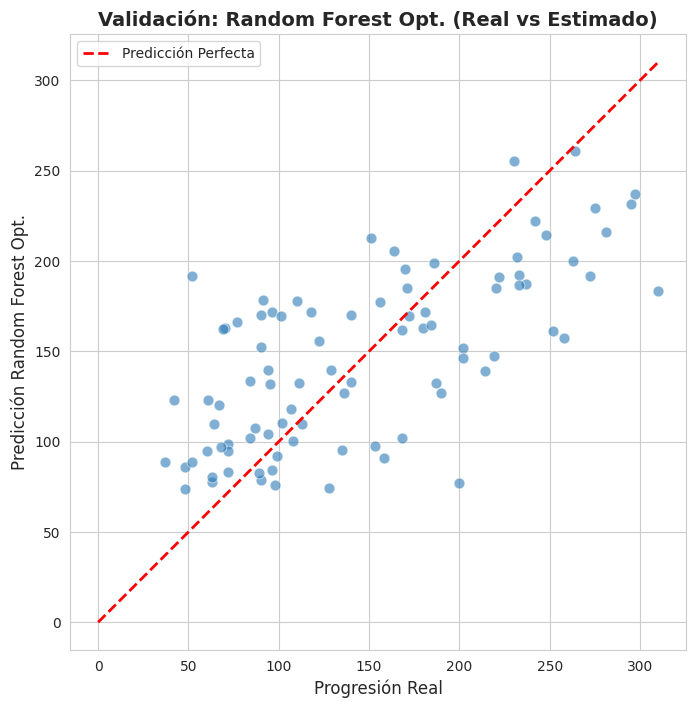

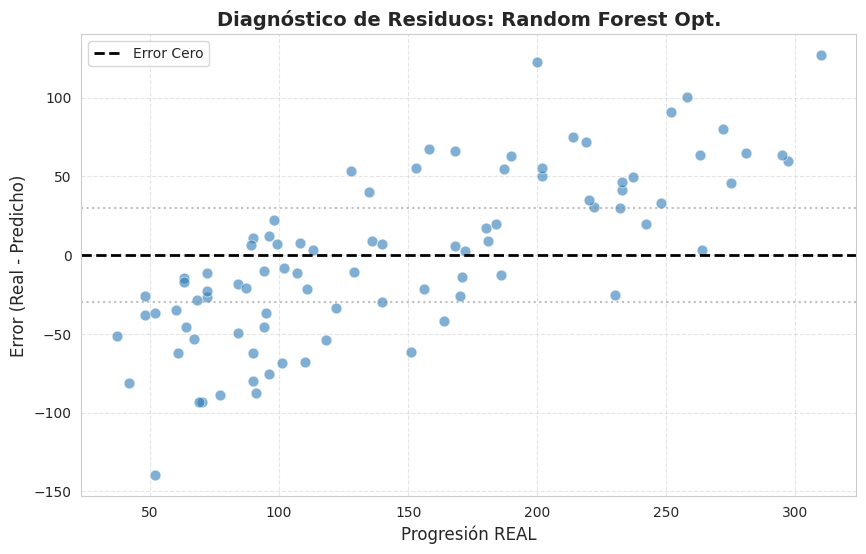

/tmp/ipykernel_18577/3518772632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


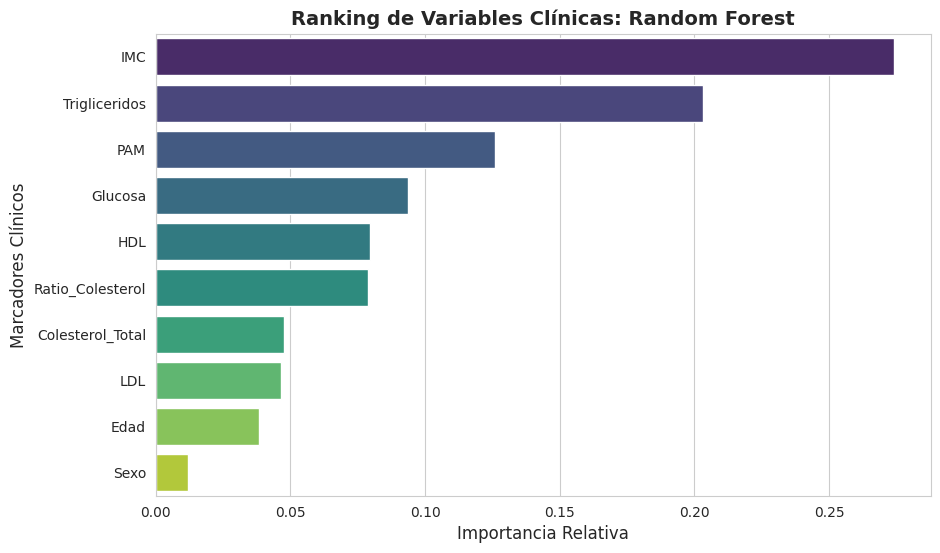

Top Variables: IMC              0.274102
Trigliceridos    0.203323
PAM              0.126048
Glucosa          0.093505
HDL              0.079638
dtype: float64


In [23]:
# Visualizaciones y Métricas
plot_real_vs_pred(best_rf, X_test, y_test, "Random Forest Opt.", color='#2c7bb6')
plot_residuals(best_rf, X_test, y_test, "Random Forest Opt.", color='#2c7bb6')
plot_feature_importance(best_rf, X_train.columns, "Random Forest", palette='viridis')
print("Top Variables:", get_top_features(best_rf, feature_names, top_n=5))

In [24]:
metricas_rf = calcular_metricas(best_rf, X_test, y_test, "Random Forest")
historial_modelos.append(metricas_rf)

### XGBoost

In [25]:
dict_params_xgb = {
    "n_estimators": [50, 100], 
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8],
    "objective": ['reg:squarederror']
}

In [26]:
grid_xgb = GridSearchCV(estimator=XGBRegressor(random_state=42, n_jobs=-1),
                        param_grid=dict_params_xgb, cv=cv_regresion, verbose=1, scoring='r2')

In [27]:
print("Entrenando XGBoost")
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print(f"\nMejores parámetros XGB: {grid_xgb.best_params_}")

--- Entrenando XGBoost ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores parámetros XGB: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'objective': 'reg:squarederror', 'subsample': 0.8}


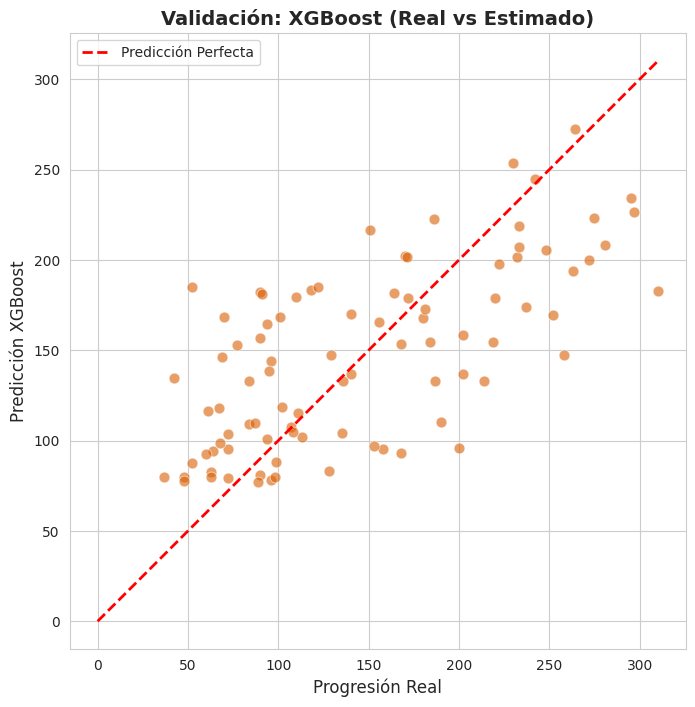

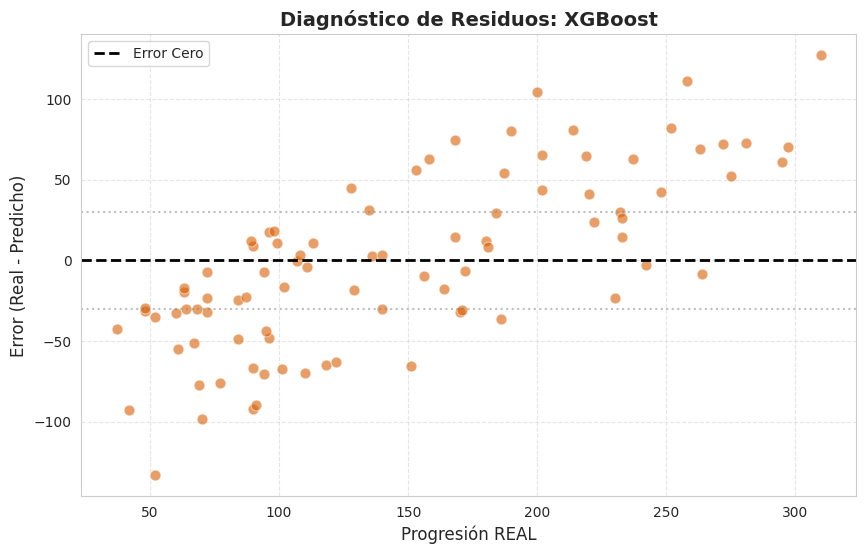

/tmp/ipykernel_18577/3518772632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


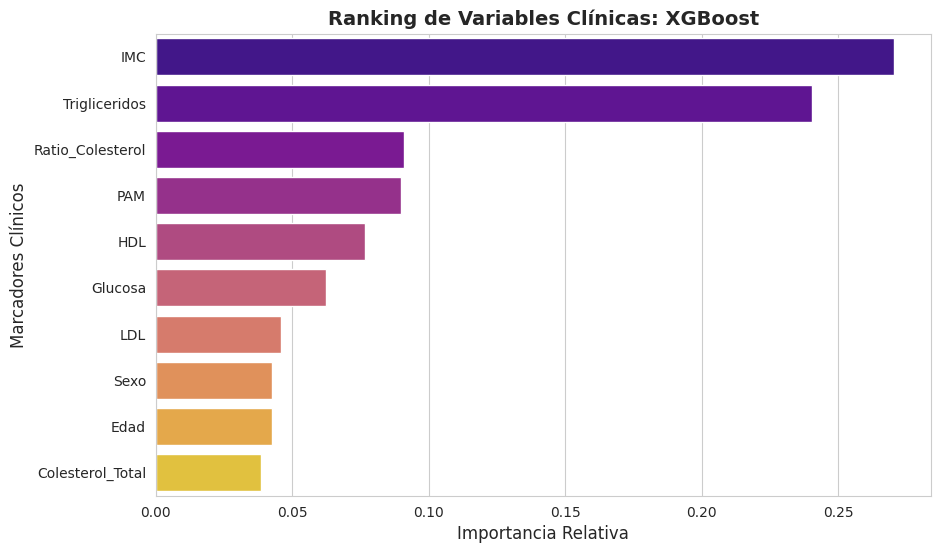

In [28]:
plot_real_vs_pred(best_xgb, X_test, y_test, "XGBoost", color='#d95f02')
plot_residuals(best_xgb, X_test, y_test, "XGBoost", color='#d95f02')
plot_feature_importance(best_xgb, X_train.columns, "XGBoost", palette='plasma')

metricas_xgb = calcular_metricas(best_xgb, X_test, y_test, "XGBoost")
historial_modelos.append(metricas_xgb)

### REGRESIÓN LINEAL

In [29]:
dict_params_lr = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0], # Fuerza de la penalización para evitar sobreajuste
    "solver": ['auto', 'svd', 'cholesky', 'saga'] # Algoritmos de resolución matemática
}

In [34]:
grid_lr = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=dict_params_lr,
    cv=cv_regresion,
    n_jobs=-1,
    verbose=1,
    scoring='r2',
    return_train_score=True
)

In [35]:
print("Entrenando Regresión Lineal Regularizada")
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print(f"\nMejores parámetros Regresión Lineal: {grid_lr.best_params_}")

Entrenando Regresión Lineal Regularizada
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros Regresión Lineal: {'alpha': 0.01, 'solver': 'auto'}


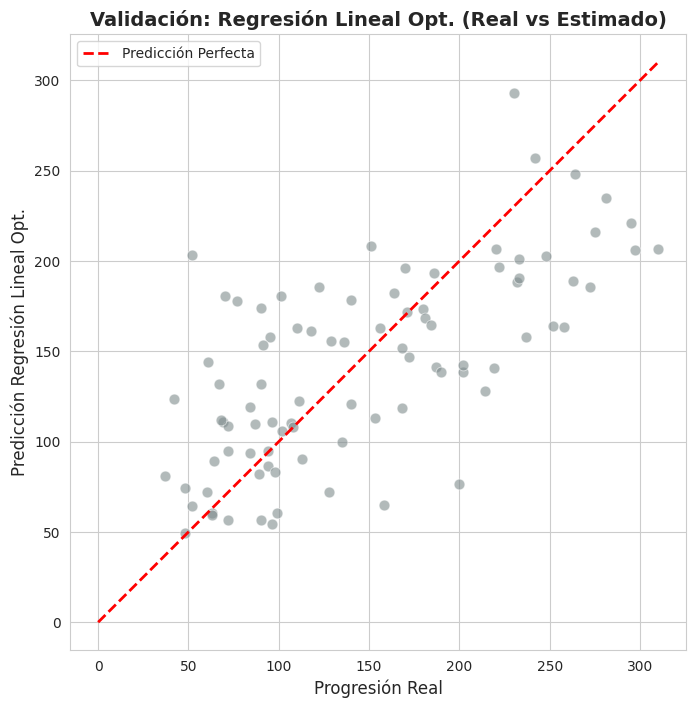

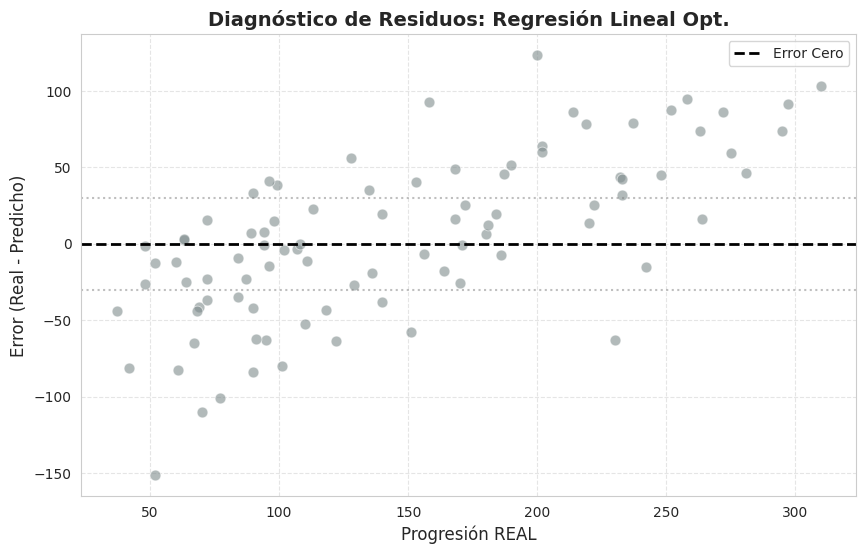

/tmp/ipykernel_18577/551908388.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')


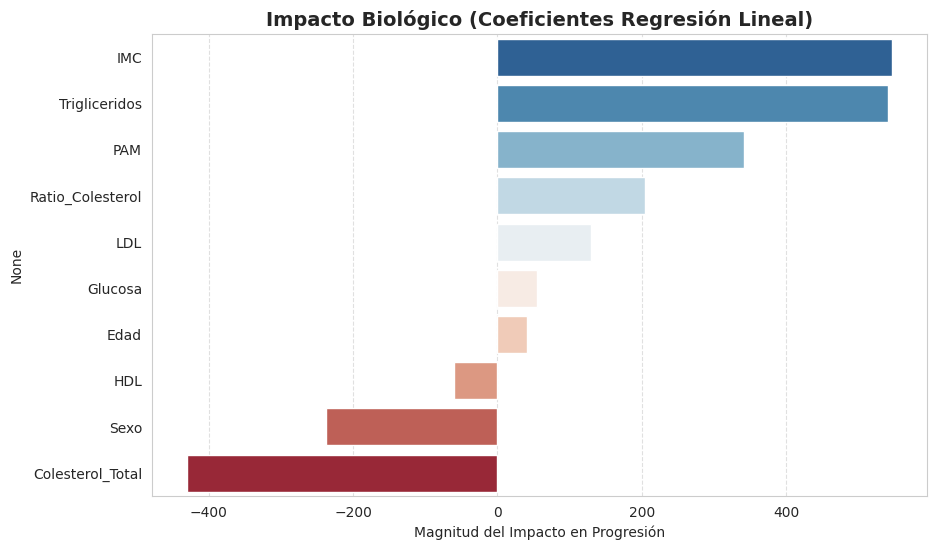

In [36]:
# 1. Gráfico Realidad vs. Predicción
plot_real_vs_pred(best_lr, X_test, y_test, "Regresión Lineal Opt.", color='#7f8c8d')

# 2. Gráfico para diagnosticar residuos
plot_residuals(best_lr, X_test, y_test, "Regresión Lineal Opt.", color='#7f8c8d')

# 3. Análisis de Coeficientes (Equivalente a la Importancia de Características)
# Nota: Los modelos lineales usan '.coef_' en lugar de '.feature_importances_'
coeficientes = pd.Series(best_lr.coef_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')
plt.title('Impacto Biológico (Coeficientes Regresión Lineal)', fontsize=14, fontweight='bold')
plt.xlabel('Magnitud del Impacto en Progresión')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

metricas_lr = calcular_metricas(best_lr, X_test, y_test, "Regresión Lineal Opt.")

historial_modelos.append(metricas_lr)

### RESULTADOS FINALES

In [39]:
df_resultados = pd.DataFrame(historial_modelos).sort_values(by='R2 (Calidad)', ascending=False)
print("\nRESULTADO FINAL")
df_resultados


RESULTADO FINAL


,Modelo,MAE,RMSE,R2 (Calidad)
0,Random Forest,43.325215,52.937803,0.471059
1,XGBoost,43.476772,53.187721,0.466053
2,Regresión Lineal Opt.,42.836888,53.686965,0.455982


**Resumen de la Comparativa Final (Simulación Clínica)**

A diferencia de procesos mecánicos, el dataset de progresión de diabetes es altamente ruidoso biológicamente. En medicina, obtener un R2 de entre 0.40 y 0.50 suele ser la norma en escenarios basales. A menudo, la regresión lineal funciona sorprendentemente bien comparada con árboles en este dataset en particular, ya que la relación principal entre IMC, Triglicéridos y Progresión tiende a seguir un comportamiento sumativo y lineal. Con la visualización de los residuos, podemos garantizar a los doctores en qué rango de progresión nuestro modelo tiende a fallar y dónde es sumamente preciso.